# Example 11b: symmetrized MAST-U Pulse Design Tool

This example uses the **FreeGSNKE Pulse Design Tool** (FPDT) to draw the dynamic of a symmetric MAST-U machine. See also example 11 and 11a. 

In [74]:
from freegsnke import build_machine, equilibrium_update, GSstaticsolver, nonlinear_solve
from freegsnke.control_loop.pcs import PlasmaControlSystem

import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from pathlib import Path
import sys

# Directory containing the notebook
notebook_dir = Path.cwd()

# Project root (one level above notebooks)
project_root = notebook_dir.parent.parent

sys.path.insert(0, str(project_root))

from freegsnke import build_machine, equilibrium_update, mastu_tools
from freegsnke.up_down_symmetry import prepare_up_down_symmetric_machine

### Instanciate Symmetric Machine

- Import symmetric machine from pickle OR
- Build a symmetric machine (see example 6c)

In [75]:
# Import tokamak machine config
pkl_file = "/Users/bf3280/Documents/freegsnke/machine_configs/MAST-U_symmetric/MAST_U_symmetric.pkl"

if Path(pkl_file).exists():
    try:
        with open( pkl_file, "rb") as f:   
            prepared = pickle.load(f)
    except Exception as e:
        print(f"Error when opening pickle file {e}")
else:

    # Configure the UDA client in the same way as examples 06a and 06b.
    os.environ["UDA_HOST"] = "uda2.hpc.l"

    # os.environ["UDA_HOST"] = "data.mastu.ukaea.uk"
    os.environ["UDA_PORT"] = "56565"
    os.environ["UDA_META_PLUGINNAME"] = "MASTU_DB"
    os.environ["UDA_METANEW_PLUGINNAME"] = "MASTU_DB"

    shot = 53320
    machine_data = mastu_tools.get_machine_data(
        shot=shot,
        split_passives=True,
    )

    active_series_raw = machine_data["active_coils_data"]
    passive_raw = machine_data["passive_coils_data"]
    limiter_raw = machine_data["limiter_data"]
    wall_raw = machine_data["wall_data"]


    try:
        prepare_up_down_symmetric_machine(
            active_series_raw,
            passive_raw,
            limiter_data=limiter_raw,
            wall_data=wall_raw,
            z_midplane="auto",
        )
    except ValueError as error:
        print(f"Safety check stopped preparation: {error}")

    # Functional call: explicitly accept exclusion of odd sources and build the
    # recentered, exactly symmetric description used from this point onward.
    prepared = prepare_up_down_symmetric_machine(
        active_series_raw,
        passive_raw,
        limiter_data=limiter_raw,
        wall_data=wall_raw,
        z_midplane="auto",
        exclude_odd_active=True,
    )


### INITIALIZATION

-- Build and draw a symmetric instance of MAST-U machine.
-- Initialize equilibrium.
-- Initialiaze profiles.
-- Initialize GS solver.

Active coils --> built from user-provided data.
Passive structures --> built from user-provided data.
Limiter --> built from user-provided data.
Wall --> built from user-provided data.
Magnetic probes --> none provided.
Resistance (R) and inductance (M) matrices --> built using actives (and passives if present).
Tokamak built.
 Solenoid : 2766.10782056
 px : 193.12768191
 d1 : 4019.86873871
 d2 : 4857.42357466
 d3 : -726.99282376
 dp : -1696.92521166
 d5 : -77.7252396
 d6 : 266.38207493
 d7 : -73.01483716
 p4 : -4169.86874271
 p5 : -4518.28147417
Forward static solve SUCCESS. Tolerance 4.82e-09 (vs. requested 1.00e-08) reached in 24/100 iterations.


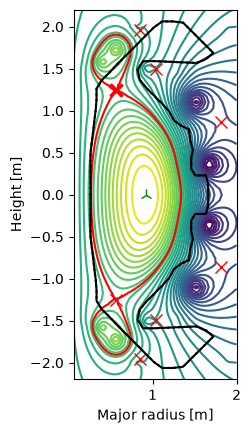

<Axes: xlabel='Major radius, $R$ [m]', ylabel='Height, $Z$ [m]'>

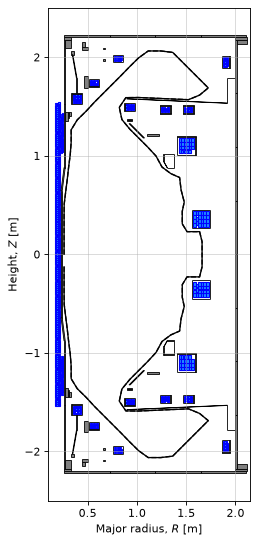

In [76]:
tokamak = build_machine.tokamak(
    active_coils_data=prepared.even_active_coils_data,
    passive_coils_data=prepared.passive_coils_data,
    limiter_data=prepared.limiter_data,
    wall_data=prepared.wall_data,
)

# Initialize equilibrium
eq = equilibrium_update.Equilibrium(
    tokamak=tokamak,
    Rmin=0.06,
    Rmax=2.0,
    Zmin=-2.2,
    Zmax=2.2,
    nx=65,
    ny=65,
    psi=None,
)

# Initialise profiles
from freegsnke.jtor_update import Lao85
profiles = Lao85(
    eq=eq,                     # equilibrium object
    Ip=7.59e5,                 # plasma current
    fvac=-0.52,                # fvac = rB_{tor}
    alpha=[362685, 17696],     # Lao profiles parameters
    beta=[0.103, 0.753],       # Lao profiles parameters
    alpha_logic=True,
    beta_logic=True,
)


# Set initial coil currents (passive structure currents start at zero here)
coil_currents = np.array([2766.10782056,   193.12768191,  4019.86873871,  4857.42357466,
        -726.99282376, -1696.92521166,   -77.7252396 ,   266.38207493,
         -73.01483716, -4169.86874271, -4518.28147417 ])

for i, key in enumerate(tokamak.coil_names[0:11]):
    print(f" {key} : {coil_currents[i]}")
    eq.tokamak.set_coil_current(coil_label=key, current_value=coil_currents[i])

# Initialise the static solver
GSStaticSolver = GSstaticsolver.NKGSsolver(eq)    

# solve for the equilbirium
GSStaticSolver.solve(
    eq=eq, 
    profiles=profiles, 
    constrain=None, 
    target_relative_tolerance=1e-8,
    )

eq.plot()

fig1, ax1 = plt.subplots(1, 1, figsize=(4, 8), dpi=80)

ax1.plot(tokamak.limiter.R, tokamak.limiter.Z, color='k', linewidth=1.2, linestyle="--")
ax1.plot(tokamak.wall.R, tokamak.wall.Z, color='k', linewidth=1.2, linestyle="-")

ax1.grid(alpha=0.5)
ax1.set_aspect('equal')
ax1.set_xlim(0.1, 2.15)
ax1.set_ylim(-2.5, 2.5)
ax1.set_xlabel(r'Major radius, $R$ [m]')
ax1.set_ylabel(r'Height, $Z$ [m]')
tokamak.plot(axis=ax1, show=False)

### Check Symmetry

The active coil and passive element configuration is checked for possible asymmetries

In [77]:
symmetric_active = True
for i,d in enumerate(prepared.even_active_coils_data.values()):
    if i >0:
        if (np.sum(d['1']['Z'] + d['2']['Z'])) != 0 or \
        np.sum(d['1']['R'] - d['2']['R']) != 0:
            print("Machine active coils are not symmetric")
            symmetric_active = False
            break
        

count_sum_0 = 0
count = 0
for i,c in enumerate(prepared.passive_coils_data):
    Zc = c["Z"]
    Rc = c['R']
    count +=1

    for j,d in enumerate(prepared.passive_coils_data):
        if j != i:
            Zd = d["Z"]
            Rd = d['R']

            if np.sum(Zd + Zc) == 0 and np.sum(Rc - Rd)==0:
                count_sum_0 +=1

if count != count_sum_0:
    print(f"Machine passive elements are not symmetric")
else:
    print("Machine passive elements are symmetric")

if symmetric_active:
    print("Machine active coils are symmetric")

Machine passive elements are symmetric
Machine active coils are symmetric


### PCS Inputs
Lists and dictionaries for each of the (internal) controller classes within the virtual PCS

In [ ]:
# active coils: must match the order they appear in FreeGSNKE machine description
active_coils = ['Solenoid', 'PX', 'D1', 'D2', 'D3', 'Dp', 'D5', 'D6', 'D7', 'P4', 'P5']

# control coils: a subset of the active coils to be used for plasma and shape parameter control (i.e. we exclude vertical control coil P6 here)
ctrl_coils = ['Solenoid', 'PX', 'D1', 'D2', 'D3', 'Dp', 'D5', 'D6', 'D7', 'P4', 'P5']

# vertical control coil
vertical_coils=[]

# names of the plasma targets (this will be clear later, equal to the number of solenoid coils)
plasma_targets = ['plasma']

### WAVEFORMS for PULSE SHAPE CONTROL DESIGN

The following quantities must be specified:

- **`ip_ref`**: Plasma current feedback reference waveform \[A\] (linear).
- **`vloop_ff`**: Loop voltage feedforward reference waveform \[V·s⁻¹\] (linear).
- **`blend`**: Control blending parameter [dimensionless] (linear):
  - `1` → purely FB control  
  - `0` → purely FF control  
  - values in `(0, 1)` → mixed FB/FF control.
- **`k_prop`**: Proportional gain waveform for the FB PID controller \[s⁻¹\] (step).
- **`k_int`**: Integral gain waveform for the FB PID controller \[s⁻²\] (step).
- **`k_deriv`**: Derivative gain waveform for the FB PID controller (no units) (step). 
- **`M_solenoid`**: Mutual inductance between the plasma and solenoid (required for FF control) \[V·s·A⁻¹\] (step).


In [79]:

tmin = 0.0
tmax = 0.5

# build the dictionary which will be passed to the virtual PCS (all keys below are required)
plasma_data = {}

# Plasma current feedback (FB) reference waveform 
plasma_data["ip_ref"] = {'times': np.array([tmin, tmax]),'vals': np.array([eq._profiles.Ip, eq._profiles.Ip])}

# Loop voltage feedforward (FF) reference waveform (can specify the desired loop voltage on the plasma)
plasma_data["vloop_ff"] = {'times': np.array([tmin, tmax]),'vals': np.array([0, 0])}

# Tell controller to use purely FB control (1), purely FF control (0), or a mixture (between 0 and 1)
# we are doing pure FB control here
plasma_data["ip_blend"] = {'times': np.array([tmin, tmax]),'vals': np.array([1, 1])}

# Proportional gain for the FB PID controller
plasma_data["k_prop"] = {'times': np.array([tmin]),'vals': np.array([-5*4])}

# Integral gain for the FB PID controller
plasma_data["k_int"] = {'times': np.array([tmin]),'vals': np.array([-50*2]) }

# Derivative gain for the FB PID controller
plasma_data["k_deriv"] = {'times': np.array([tmin]),'vals': np.array([0])}

# Mutual inductance between plasma and solenoid
plasma_data["M_solenoid"] = {"times": np.array([tmin]),  "vals": np.array([1.0])}

plasma_data.keys()

dict_keys(['ip_ref', 'vloop_ff', 'ip_blend', 'k_prop', 'k_int', 'k_deriv', 'M_solenoid'])

In [166]:

def plasma_descriptors(eq):
    ''' This function extracts four plasma geometry descriptors (R_in, R_out, R_x, Z_x)
    R_in = inboard separatrix radius at the midplane
    R_out = outboard separatrix radius at the midplane
    (RX,ZX) = selected lower X-point coordinates
    '''

    # inboard/outboard midplane radii
    RinRout = eq.innerOuterSeparatrix()

    # find lower X-point
    # define a "box" in which to search for the lower X-point
    XPT_BOX = [[0.33, -0.88], [0.95, -1.38]]

    # mask those points
    xpt_mask = (
        (eq.xpt[:, 0] >= XPT_BOX[0][0])
        & (eq.xpt[:, 0] <= XPT_BOX[1][0])
        & (eq.xpt[:, 1] <= XPT_BOX[0][1])
        & (eq.xpt[:, 1] >= XPT_BOX[1][1])
    )
    xpts = eq.xpt[xpt_mask, 0:2].squeeze()
    if xpts.ndim > 1 and xpts.shape[0] > 1:
        opt = eq.opt[0, 0:2]
        dists = np.linalg.norm(xpts - opt, axis=1)
        idx = np.argmin(dists)  # index of closest point
        Rx, Zx = xpts[idx, :]
    else:
        Rx, Zx = xpts

    return np.array([RinRout[0], RinRout[1], Rx, Zx])

baseline_descriptors = plasma_descriptors(eq)

# give these descriptors some names for use in the PCS
ctrl_targets = ['Rin','Rout', 'Rx', 'Zx']


In [ ]:
# build the dictionary which will be passed to the virtual PCS (all keys below are required)
shape_data = {}

# waveforms for Rin
shape_data["Rin"] = {}
shape_data["Rin"]["ff"] = {"times": np.array([tmin, tmax]), "vals": np.array([0.0, 0.0])}          
shape_data["Rin"]["ref"] = {"times": np.array([tmin, tmax]), "vals": np.array([0.28, 0.28])} 
shape_data["Rin"]["blend"] = {"times": np.array([tmin, tmax]), "vals": np.array([1.0, 1.0])}
shape_data["Rin"]["k_prop"] = {"times": np.array([tmin]), "vals": np.array([120])}
shape_data["Rin"]["k_int"] = {"times": np.array([tmin]), "vals": np.array([0.0])}
shape_data["Rin"]["k_deriv"] = {"times": np.array([tmin]), "vals": np.array([0.0])}

# waveforms for Rout
shape_data["Rout"] = {}
shape_data["Rout"]["ff"] = {"times": np.array([tmin, tmax]), "vals": np.array([0.0, 0.0])}        
shape_data["Rout"]["ref"] = {"times": np.array([tmin, tmax]), "vals": np.array([1.35, 1.35])} 
shape_data["Rout"]["blend"] = {"times": np.array([tmin, tmax]), "vals": np.array([1.0, 1.0])}
shape_data["Rout"]["k_prop"] = {"times": np.array([tmin]), "vals": np.array([120])}
shape_data["Rout"]["k_int"] = {"times": np.array([tmin]), "vals": np.array([0.0])}
shape_data["Rout"]["k_deriv"] = {"times": np.array([tmin]), "vals": np.array([0.0])}

# waveforms for Rx
shape_data["Rx"] = {}
shape_data["Rx"]["ff"] = {"times": np.array([tmin, tmax]), "vals": np.array([0.0, 0.0])}       
shape_data["Rx"]["ref"] = {"times": np.array([tmin, 0.025, 0.075, 0.175, 0.225, tmax]), "vals": np.array([0.57, 0.57, 0.5, 0.5, 0.57, 0.57])}  # we vary Rx
shape_data["Rx"]["blend"] = {"times": np.array([tmin, tmax]), "vals": np.array([1.0, 1.0])}
shape_data["Rx"]["k_prop"] = {"times": np.array([tmin]), "vals": np.array([120])}
shape_data["Rx"]["k_int"] = {"times": np.array([tmin]), "vals": np.array([0.0])}
shape_data["Rx"]["k_deriv"] = {"times": np.array([tmin]), "vals": np.array([0.0])}

# waveforms for Zx
shape_data["Zx"] = {}
shape_data["Zx"]["ff"] = {"times": np.array([tmin, tmax]), "vals": np.array([0.0, 0.0])}         
shape_data["Zx"]["ref"] = {"times": np.array([tmin, tmax]), "vals": np.array([-1.24, -1.24])}   
shape_data["Zx"]["blend"] = {"times": np.array([tmin, tmax]), "vals": np.array([0.0, 0.0])}
shape_data["Zx"]["k_prop"] = {"times": np.array([tmin]), "vals": np.array([120])}
shape_data["Zx"]["k_int"] = {"times": np.array([tmin]), "vals": np.array([0.0])}
shape_data["Zx"]["k_deriv"] = {"times": np.array([tmin]), "vals": np.array([0.0])}

shape_data.keys()

dict_keys(['Rin', 'Rout', 'Rx', 'Zx'])

In [168]:
# VIRTUAL CIRCUITS CATEGORY

# build the dictionary which will be passed to the virtual PCS (all keys below are required) Control coils
circuits_data = {}

circuits_data["Rin"] = {
 "times": np.array([tmin]), 
    "vals": [
        np.array([0, 3.1394e+04,  8.5990e+03, -8.8300e+02, -1.2460e+03, -6.6690e+03, 1.2660e+03,  2.9770e+03,  3.5350e+03,  8.3110e+03, -7.8520e+03]),
        ]
    }

circuits_data["Rout"] = {
    "times": np.array([tmin]), 
    "vals": [
        np.array([0, -9.9700e+02,  1.1790e+03,  3.9700e+02, -2.0000e+02, -1.8970e+03, -5.5500e+02, -2.2640e+03, -1.5860e+03, -1.9750e+03,  5.5800e+03]),
        ]
    }

circuits_data["Rx"] = {
    "times": np.array([tmin]), 
    "vals": [
        np.array([0, -3.0021e+04,  3.3980e+03,  8.6900e+03,  5.8310e+03,  1.5858e+04, 2.4000e+01, -1.2100e+02, -2.2160e+03, -9.5290e+03,  1.3570e+03]),
        ]
    }

circuits_data["Zx"] = {
    "times": np.array([tmin]), 
    "vals": [
        np.zeros(11),
        ]
    }

circuits_data["plasma"] = {
    "times": np.array([tmin]), 
    "vals": [
        np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
        ]
    }

# store the coil order for future reference
circuits_data["coil_order"] = ctrl_coils

# define any feedforward coil current drives on each control coil (no drives used here)
zeros_dict = {"times": np.array([tmin, tmax]), "vals": np.array([0.0, 0.0])}
for coil in ctrl_coils: # linearly interpolated
    circuits_data[coil+"_ref"] = zeros_dict

circuits_data.keys()

dict_keys(['Rin', 'Rout', 'Rx', 'Zx', 'plasma', 'coil_order', 'Solenoid_ref', 'PX_ref', 'D1_ref', 'D2_ref', 'D3_ref', 'Dp_ref', 'D5_ref', 'D6_ref', 'D7_ref', 'P4_ref', 'P5_ref'])

In [169]:
# SYSTEMS CATEGORY

# build the dictionary which will be passed to the virtual PCS (all keys below are required)
systems_data = {}

# define the min coil current limits and ramp rate limits
systems_data["min_coil_curr_lims"] = {
    'times': [0.0],
    'vals': [np.array([-10000, -7000, -9000, -9000, -9000, -9000, -9000, -9000, -9000, -10000, -10000])],
    }

# define the max coil current limits
systems_data["max_coil_curr_lims"] = {
    'times': [0.0],
    'vals': [np.array([10000, 7000, 9000, 9000, 9000, 9000, 9000, 9000, 9000, 0, 0])],
    }

# define the max ramp rate limits for the coils
systems_data["max_coil_curr_ramp_lims"] = {
    'times': [0.0],
    'vals': [1e12*np.ones(len(ctrl_coils))],
    }

# define the control coil current perturbations
for name in ctrl_coils: # linearly interpolated
    systems_data[name+"_pert"] = zeros_dict

systems_data.keys()

dict_keys(['min_coil_curr_lims', 'max_coil_curr_lims', 'max_coil_curr_ramp_lims', 'Solenoid_pert', 'PX_pert', 'D1_pert', 'D2_pert', 'D3_pert', 'Dp_pert', 'D5_pert', 'D6_pert', 'D7_pert', 'P4_pert', 'P5_pert'])

In [170]:
# PF CATEGORY

# build the dictionary which will be passed to the virtual PCS (all keys below are required)
pf_data = {}

# coil resistances
pf_data["R_matrix"] = {
    'times': [0.0],
    'vals': [tokamak.coil_resist[0:11]],
    }

# coil mutual inductances (on feedforward terms)
pf_data["M_FF_matrix"] = {
    'times': [0.0],
    'vals': [tokamak.coil_self_ind[0:11,0:11]],
    }

# coil mutual inductances (on feedback terms)
pf_data["M_FB_matrix"] = {
    'times': [0.0],
    'vals': [tokamak.coil_self_ind[0:11,0:11]],
    }


# gains on the coils (for feedback term)
pf_data["coil_gains"] = {
    'times': [0.0],
    'vals': [0.015*np.ones(len(ctrl_coils))],
    }

# limits on voltages in the coils
pf_data["coil_voltage_lims"] = {
    "times": np.array([0.0]),
    'vals': [[2000,  750,  750,  750,  750,  750,  750,  750,  750,  750,  750]],
     } 

# limits on voltage ramp rates in the coils (we set no limits here)
pf_data["coil_voltage_slew_lims"] = {
    'times': [0.0],
    'vals': [1e12*np.ones(len(ctrl_coils))],
    }

pf_data.keys()

dict_keys(['R_matrix', 'M_FF_matrix', 'M_FB_matrix', 'coil_gains', 'coil_voltage_lims', 'coil_voltage_slew_lims'])

In [171]:
# build the dictionary which will be passed to the virtual PCS (all keys below are required)
vertical_data = {}

# plasma vertical position reference
vertical_data["z_ref"] = {"times": np.array([tmin, tmin+0.125, tmax]), "vals": np.array([0.0, 0.01, 0.01])}

# proportional gain
vertical_data["k_prop"] = {"times": np.array([tmin]), "vals": np.array([0.025])}

# derivative gain
vertical_data["k_deriv"] = {"times": np.array([tmin]), "vals": np.array([5e-7])}

vertical_data.keys()

dict_keys(['z_ref', 'k_prop', 'k_deriv'])

In [172]:
# COIL ACTIVATIONS CATEGORY

# build the dictionary which will be passed to the virtual PCS (all keys below are required)
coil_activation_data = {}

# coil activation times
default_coil_dict = {"times": np.array([tmin]), "vals": np.array([1.0])}
for name in active_coils:
    coil_activation_data[name+"_activation"] = default_coil_dict

coil_activation_data.keys()

dict_keys(['Solenoid_activation', 'px_activation', 'd1_activation', 'd2_activation', 'd3_activation', 'dp_activation', 'd5_activation', 'd6_activation', 'd7_activation', 'p4_activation', 'p5_activation'])

### Initialise the virtual PCS class

This will build internal classes for each of the above listed controllers. 

In [173]:
# FIRE UP THE PLASMA CONTROL SYSTEM

PCS = PlasmaControlSystem(
    plasma_data=plasma_data,
    shape_data=shape_data,
    shape_control_mode="PID",
    circuits_data=circuits_data,
    systems_data=systems_data,
    pf_data=pf_data,
    vertical_data=vertical_data,
    coil_activation_data=coil_activation_data,
    active_coils=active_coils,
    ctrl_coils=ctrl_coils,
    vertical_coils=vertical_coils,
    ctrl_targets=ctrl_targets,
    plasma_target=plasma_targets
    )

In [174]:
PCS.CoilActivationController.data
PCS.PlasmaController.data
PCS.PlasmaController.interpolants
PCS.PlasmaController.run_control

<bound method PlasmaController.run_control of <freegsnke.control_loop.plasma_category.PlasmaController object at 0x34e187810>>

### Initialise the nonlinear solver object

**SymmetryReducedSolver** enforces symmetric GS solves and removes odd passive
modes before calculating plasma coupling. Let (S_m) reflect metal currents and
(S_y) reflect the plasma grid. Exact symmetry gives

$$
S_m^2=S_y^2=I,
\qquad S_m^T=S_m,
\qquad S_m A_m=A_m S_m,
$$

where $(A_m=R_m^{-1}L_m)$ is the passive circuit operator. Thus the even and odd
metal-current subspaces are orthogonal and dynamically independent. The plasma
response obeys the corresponding parity relation, so its linearisation is
projected with

$
\Pi_+ = \frac{I+S_y}{2}.
$

Ten reflected passive pairs provide ten even and ten odd passive modes. Six even
modes are retained here, alongside all five active circuits and the total
plasma-current coordinate. The next plot shows which passive modes remain.

The full evolutive timestep is 2.5 ms. For comparison, Example 11 uses 0.5 ms;
removing the fast odd vertical dynamics permits a fivefold increase here. The
timestep must still resolve the retained even dynamics and the chosen controller
gains.


In [175]:
from freegsnke.symmetry_reduced_solve import SymmetryReducedSolver

stepping = SymmetryReducedSolver(
    eq=eq,
    profiles=profiles,
    GSStaticSolver=GSStaticSolver,
    full_timestep=2.5e-3,
    max_internal_timestep=2.5e-3,
    plasma_resistivity=1e-7,
    fix_n_vessel_modes=6,
    plasma_descriptor_function=plasma_descriptors,
    passive_reflection_operator=prepared.passive_reflection_operator,
    verbose=False,
)

active_coils = list(tokamak.coils_list[: tokamak.n_active_coils])
n_active = len(active_coils)

retained_parity = (
    stepping.evol_metal_curr.normal_modes.passive_mode_parity[
        stepping.evol_metal_curr.selected_modes_mask[n_active:]
    ]
)

def reduced_columns_reflection_error(columns):
    fields = np.zeros((stepping.nx, stepping.ny, columns.shape[1]))
    fields[stepping.limiter_handler.mask_inside_limiter] = columns
    return np.linalg.norm(fields - fields[:, ::-1]) / np.linalg.norm(fields)


print("Retained metal modes:", stepping.n_metal_modes)
print("Retained passive parities:", np.unique(retained_parity))
print("dIydI parity error:", reduced_columns_reflection_error(stepping.dIydI))
print("dIydtheta parity error:", reduced_columns_reflection_error(stepping.dIydtheta))
assert np.all(retained_parity == 1)
assert reduced_columns_reflection_error(stepping.dIydI) < 1e-14
assert reduced_columns_reflection_error(stepping.dIydtheta) < 1e-14


-----
Checking that the provided 'eq' and 'profiles' are a GS solution...
Forward static solve SUCCESS. Tolerance 3.88e-09 (vs. requested 1.00e-08) reached in 0/100 iterations.
-----
Instantiating nonlinear solver objects...
done.
-----
Identifying mode selection criteria...
      'fix_n_vessel_modes' option selected --> passive structure modes that couple most to the strongest passive structure mode are being selected.
-----
Initial mode selection:
   Active coils
      total selected = 11 (out of 11)
   Passive structures
      6 selected using 'fix_n_vessel_modes'
   Total number of modes = 17 (11 active coils + 6 passive structures)
      (Note: some additional modes may be removed after Jacobian calculation if 'mode_removal=True')
-----
Building the 1786 x 18 Jacobian (dIy/dI) of plasma current density (inside the LCFS) with respect to all metal currents and the total plasma current.
Building the 1786 x 4 Jacobian (dIy/dtheta) of plasma current density (inside the LCFS) with respe

In [176]:
# FPDT SETUP

# number of simulation time steps
n = 100

# simulation time step size (must be smaller than the vertical instability timescale)
dt = stepping.dt_step

# PCS time step (this must be whole fraction of the simulation time step)
# it governs the frequency at which the PCS is called
dt_PCS = dt/2

# automatically calculates time array and sets time step in solver object
t_end = tmin + n*dt
times = np.arange(tmin, t_end, dt)

# (re-)initialise the dynamic solver with the initial eq and profiles
stepping.initialize_from_ICs(eq, profiles)

In [177]:
# equilibrium-related data storage
dynamic_psi = np.zeros((stepping.eq1.psi().shape[0], stepping.eq1.psi().shape[1], len(times)))    # total poloidal flux
dynamic_limiter_flag = np.zeros(len(times))                                                       # flag if plasma is limited
dynamic_psi_boundary = np.zeros(len(times))                                                       # poloidal flux on plasma boundary
dynamic_xpts = []                                                                                 # list of X-point locations and associated poloidal flux
dynamic_opts = []                                                                                 # list of O-point locations and associated poloidal flux
dynamic_currents = np.zeros((len(stepping.vessel_currents_vec),len(times)))                         # PF coil and vessel eigenmode currents 
dynamic_ip = np.zeros(len(times))                                                                 # total plasma current
dynamic_shape_targets = np.zeros((len(ctrl_targets),len(times)))                                  # shape parameters
dynamic_triangularity = np.zeros(len(times))                                                      # plasma triangularity
linear_growth_rate = np.zeros(len(times))                                                         # linearised (deformable) growth rate estimate

# PCS-related data storage
V_approved = np.zeros((len(ctrl_coils),len(times)))                                             # final PF coil voltages from the PCS class (passed into solver)
ip_hist = np.zeros(len(times))                                                                    # integral term feeding into Plasma Category PID FB controller (at prior time step)
ip_err = np.zeros(len(times))                                                                     # (error) for derivative term feeding into Plasma Category PID FB controller (at prior time step)
T_err = np.zeros((len(ctrl_targets),len(times)))                                                  # proportional term feeding into Shape Category PID FB controller (at prior time step)
T_hist = np.zeros((len(ctrl_targets),len(times)))                                                 # integral term feeding into Shape Category PID FB controller (at prior time step)
I_approved = np.zeros((len(ctrl_coils),len(times)))                                               # approved PF coil currents from prior time step feeding into System Category
coil_resists = np.zeros((len(active_coils),len(times)))                                        # PF coil resistances (to tell solver if a coil is switched on or off)
z_current = np.zeros(len(times))                                                                  # vertical position of the plasma (average jtor position)
dynamic_timings = np.zeros(len(times))                                                            # solver runtime at each time step
dynamic_jtor_norm = np.zeros(len(times))                                                          # norm change in jtor between time steps (used to trigger relinearisation)
threshold = 0.05    
voltages = np.zeros((n_active, n - 1))                                                                              # relative jtor threshold (since last linearisation) above which relinearisation is triggered (here not used)

# extract any initial values from the initial equilibrium
dynamic_psi[:,:,0] = stepping.eq1.psi()
dynamic_limiter_flag[0] = stepping.eq1._profiles.flag_limiter
dynamic_psi_boundary[0] = stepping.eq1._profiles.psi_bndry
dynamic_xpts.append(stepping.eq1.xpt)
dynamic_opts.append(stepping.eq1.opt)
dynamic_currents[:,0] = stepping.vessel_currents_vec.copy()
dynamic_ip[0] = stepping.profiles1.Ip
dynamic_shape_targets[:,0] = plasma_descriptors(eq=stepping.eq1)
dynamic_triangularity[0] = eq.triangularity()
linear_growth_rate[0] = np.max(np.real(stepping.linearised_sol.all_timescales))
z_current[0] = stepping.eq1.Zcurrent()

In [ ]:
import time
# RUN FPDT SIMULATION
for i, t in enumerate(times[0:-1]):
    print("-----")
    print(f"t = {np.round(t,5)}s (step {i+1}/{n-1})")
    
    # start timer
    start_time = time.time()

    # initialise any historical quantities for PCS PID controllers
    if i == 0:
        ip_hist_prev = 0.0
        ip_err_prev = 0.0
        T_err_prev = np.zeros(len(ctrl_targets))
        T_hist_prev = np.zeros(len(ctrl_targets))
        I_approved_prev = eq.tokamak.getCurrentsVec()[0:11]  # must use starting currents here
        V_approved_prev = np.zeros(len(ctrl_coils))
        zipv_meas = 0.0
    else:
        ip_hist_prev=ip_hist[i].copy()                              # integral term from FB PID Plasma controller at prior step
        ip_err_prev=ip_err[i].copy()                                # error term from FB PID Plasma controller at prior step
        T_err_prev=T_err[:,i].copy()                                # proportional term from FB PID Shape controller at prior step
        T_hist_prev=T_hist[:,i].copy()                              # integral term from FB PID Shape controller at prior step
        I_approved_prev=I_approved[:,i].copy()                      # approved PF coil currents from prior step (ctrl_coils only)
        V_approved_prev=V_approved[0,i].copy()                   # approved PF coil voltages from prior step (ctrl_coils only)
        zipv_meas = ((z_current[i]-z_current[i-1])/dt)*dynamic_ip[i]  # rate of change of vertical plasma position 

    # # if you wish to calculate new VCs on the fly uncomment below
    # vcg_inputs = VCG.get_inputs_from_eq(eq=stepping.eq1, profiles=stepping.profiles1)
    
    # call the PCS class to attain PF coil voltages (on ctrl_coils and vertical coil)
    V_approved[:,i], ip_hist[i], ip_err[i], T_err[:,i], T_hist[:,i], I_approved[:,i], coil_resists[:,i] = PCS.calculate_ctrl_voltages(
        t=t,                                        # current simulation time
        dt=dt_PCS,                                  # PCS time step
        dt_simulator=dt,                            # simulator (solver) time step
        ip_meas=dynamic_ip[i],                      # measured plasma current
        ip_hist_prev=ip_hist_prev,                  # plasma controller integral term history
        ip_err_prev=ip_err_prev,                    # plasma controller error term history (for derivative term)
        T_meas=dynamic_shape_targets[:,i].copy(),   # measured shape parameters
        T_err_prev=T_err_prev,                      # shape controller proportional term history
        T_hist_prev=T_hist_prev,                    # shape controller integral term history
        I_approved_prev=I_approved_prev,            # approved PF currents from prior timestep
        I_meas=dynamic_currents[0:11,i].copy(),     # measured PF coil currents
        V_approved_prev=V_approved_prev,            # approved PF voltages from prior timestep
        zip_meas=z_current[i]*dynamic_ip[i],        # measured vertical position x measured plasma current
        zipv_meas=zipv_meas,                        # derivative of above
        active_coil_resists=tokamak.coil_resist[0:11].copy(),    # PF coil resistances (these are constant)
        verbose=False,                              # print some output?
        # vcg_inputs=vcg_inputs,                      # pass in eq and profiles at each time to re-calculate VCs after each time period (vc_update_rate)
    )
    voltages[:,i] = V_approved[:,i]
    # extract plasma current density profile parameters (these are constant but can be time-dependent if desired)
    profile_params = {
            "alpha": profiles.alpha[0:2],
            "beta": profiles.beta[0:2],
            }

    # run freegsnke over the time step with the calculated voltages
    stepping.nlstepper(
        plasma_resistivity=1e-7,                          # assign plasma resistivity (chosen to be constant here)
        active_voltage_vec=V_approved[:,i],               # assign approved PF coil voltages from the PCS
        profiles_parameters=profile_params,               # assign profile parameters
        custom_active_coil_resistances=coil_resists[:,i], # assign active coil resistances from PCS (tells solver if any coils are switched off)
        linear_only=True,                                 # linear or nonlinear solve?
        target_relative_tol_currents=1e-2,                # relative tolerance in the currents required for convergence
        target_relative_tol_GS=1e-2,                      # relative tolerance in the plasma flux required for convergence
        working_relative_tol_GS=(1e-2)/2,                 # tolerance used when solving GS equation, expressed in terms of the change in the plasma flux due to one timestep of evolution (must be smaller tolerance above)
        max_solving_iterations=20,                        # stop after this many iterations
        verbose=False,                                    # print some output?
        relinearise_threshold=threshold,                  # if the relative jtor norm change from last linearisation is above threshold, relinearise around current equilibrium
        no_GS=False,                                      # do not solve GS at each time?
        )

    stepping.eq1.plot()

    # stop timer
    end_time = time.time()

    # extract and store relevant data
    dynamic_psi[:,:,i+1] = stepping.eq1.psi()
    dynamic_limiter_flag[i+1] = stepping.eq1._profiles.flag_limiter
    dynamic_psi_boundary[i+1] = stepping.eq1._profiles.psi_bndry
    dynamic_xpts.append(stepping.eq1.xpt)
    dynamic_opts.append(stepping.eq1.opt)
    dynamic_currents[:,i+1] = stepping.vessel_currents_vec.copy()
    dynamic_ip[i+1] = stepping.currents_vec[-1] * stepping.plasma_norm_factor
    dynamic_shape_targets[:,i+1] = plasma_descriptors(stepping.eq1)
    dynamic_timings[i] = end_time - start_time
    dynamic_triangularity[i] = stepping.eq1.triangularity()
    z_current[i+1] = stepping.eq1.Zcurrent()
    dynamic_jtor_norm[i+1] = stepping.relinearise_criteria
    stepping.linearised_sol.calculate_linear_growth_rate()
    linear_growth_rate[i+1] = np.max(np.real(stepping.linearised_sol.all_timescales))

    # print some stuff to track solve
    print(f"      PLASMA QUANTITIES")
    print(f"        Ip = {np.round(dynamic_ip[i+1]/1000,1)} [kA]")
    print(f"        Shape parameters {ctrl_targets} = {np.round(dynamic_shape_targets[:,i+1],3)}")
    print(f"        Z position = {np.round(z_current[i+1],5)} [m]")
    print(f"        Linearised (deformable) growth rate = {np.round(1/linear_growth_rate[i+1],3)} [1/s]")
    print(f"      SOLVER STATUS")
    print(f"        Relinearisation status = {np.round(dynamic_jtor_norm[i+1],3)} (threshold = {threshold}) ")

    # break if growth rate timescale exceeds timestep multiple
    # if dt > linear_growth_rate[i+1]:
    #     print("      BREAKING LOOP - INSTABILITY TIMESCALE EXCEEDS TIMESTEP SIZE")
    #     break


-----
t = 0.0s (step 1/99)
      PLASMA QUANTITIES
        Ip = 757.3 [kA]
        Shape parameters ['Rin', 'Rout', 'Rx', 'Zx'] = [ 0.268  1.34   0.561 -1.251]
        Z position = -0.0 [m]
        Linearised (deformable) growth rate = -3184.749 [1/s]
      SOLVER STATUS
        Relinearisation status = 0.0 (threshold = 0.05) 
-----
t = 0.0025s (step 2/99)
      PLASMA QUANTITIES
        Ip = 753.2 [kA]
        Shape parameters ['Rin', 'Rout', 'Rx', 'Zx'] = [ 0.284  1.344  0.563 -1.247]
        Z position = -0.0 [m]
        Linearised (deformable) growth rate = -3184.749 [1/s]
      SOLVER STATUS
        Relinearisation status = 0.004 (threshold = 0.05) 
-----
t = 0.005s (step 3/99)
      PLASMA QUANTITIES
        Ip = 748.7 [kA]
        Shape parameters ['Rin', 'Rout', 'Rx', 'Zx'] = [ 0.304  1.347  0.564 -1.24 ]
        Z position = -0.0 [m]
        Linearised (deformable) growth rate = -3184.749 [1/s]
      SOLVER STATUS
        Relinearisation status = 0.046 (threshold = 0.05) 
----

ValueError: not enough values to unpack (expected 2, got 0)

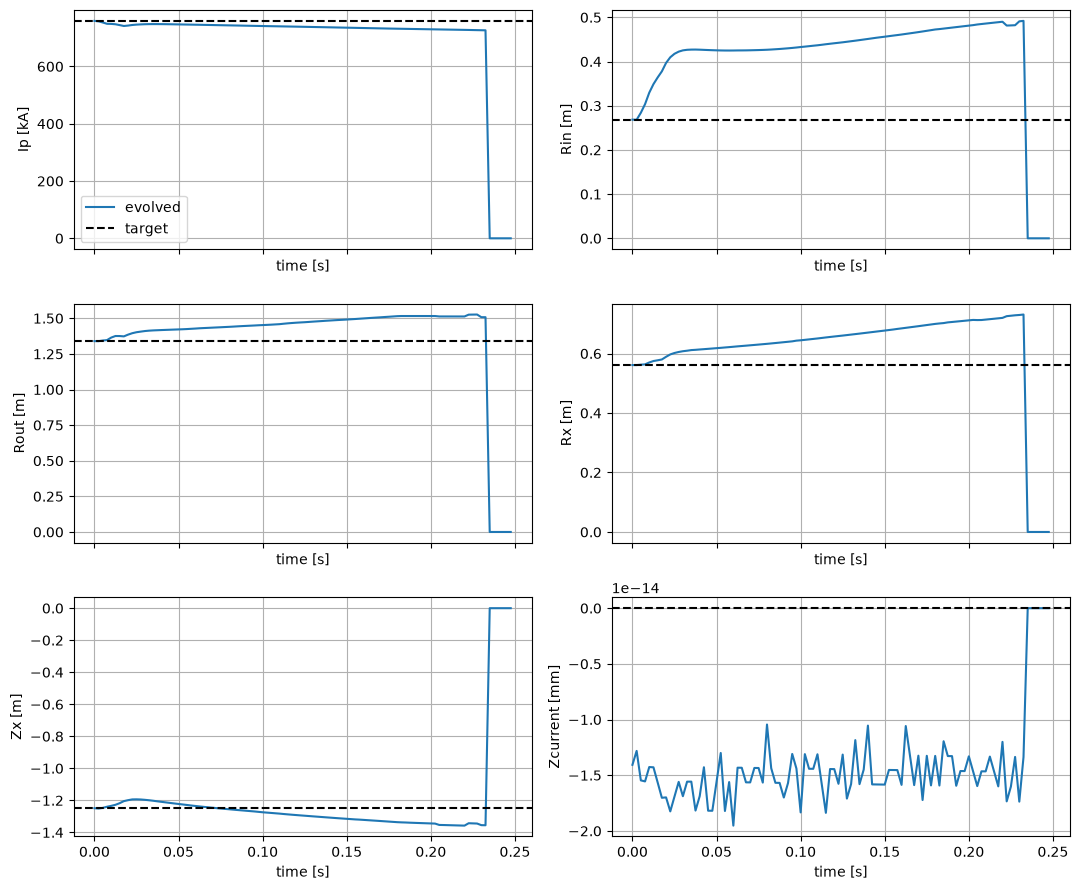

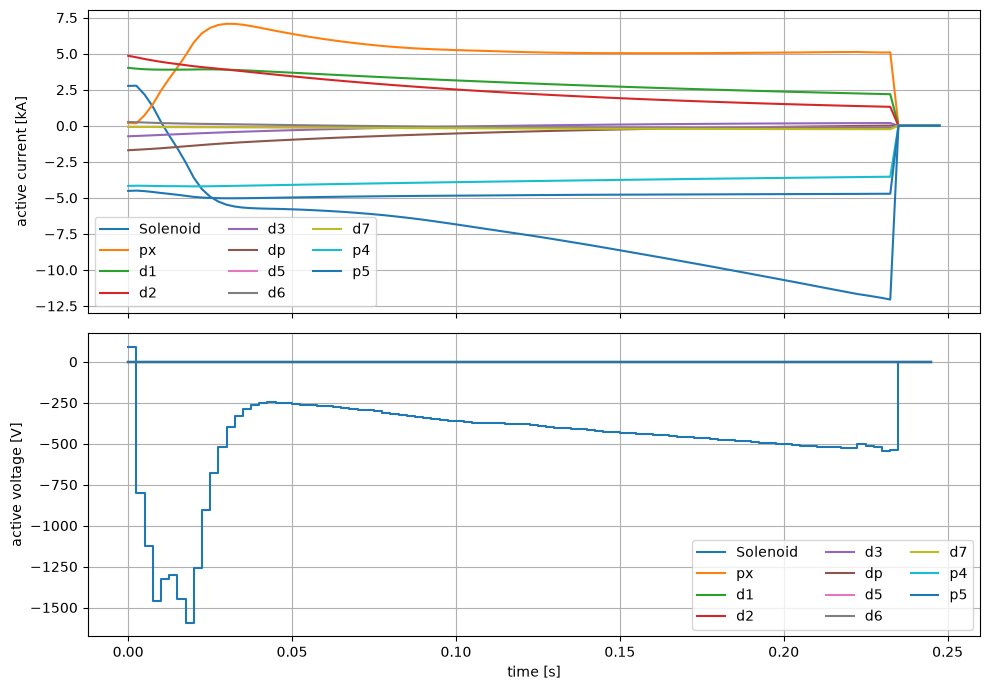

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex=True)
axes = axes.ravel()
axes[0].plot(times, dynamic_ip / 1e3, label="evolved")
axes[0].axhline(profiles.Ip / 1e3, color="k", linestyle="--", label="target")
axes[0].set_ylabel("Ip [kA]")
axes[0].legend()

for target_index, target in enumerate(ctrl_targets, start=1):
    axis = axes[target_index]
    axis.plot(times, dynamic_shape_targets[target_index - 1], label="evolved")
    axis.axhline(
        baseline_descriptors[target_index - 1],
        color="k",
        linestyle="--",
        label="target",
    )
    axis.set_ylabel(f"{target} [m]")

axes[5].plot(times, 1e3 * z_current)
axes[5].axhline(0.0, color="k", linestyle="--")
axes[5].set_ylabel("Zcurrent [mm]")
for axis in axes:
    axis.grid(True)
    axis.set_xlabel("time [s]")
fig.tight_layout()
plt.show()

fig, (current_axis, voltage_axis) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for coil_index, coil_name in enumerate(active_coils):
    current_axis.plot(
        times,
        dynamic_currents[coil_index] / 1e3,
        label=coil_name,
    )
    voltage_axis.step(
        times[:-1],
        voltages[coil_index],
        where="post",
        label=coil_name,
    )
current_axis.set_ylabel("active current [kA]")
voltage_axis.set_ylabel("active voltage [V]")
voltage_axis.set_xlabel("time [s]")
for axis in (current_axis, voltage_axis):
    axis.grid(True)
    axis.legend(ncol=3)
fig.tight_layout()
plt.show()